In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# 1. Specify the correct file name inside the dataset
file_path = "spam.csv" 

# 2. Use dataset_load() instead of load_dataset() to avoid the deprecation warning
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "uciml/sms-spam-collection-dataset",
    file_path,
    # The SMS dataset often uses 'latin-1' or 'utf-8-sig' encoding
    pandas_kwargs={"encoding": "latin-1"} 
)

print("First 5 records:")
print(df.head())

First 5 records:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [3]:
df.shape

(5572, 5)

In [4]:
#1 data cleaning
#2 EDA
#3 Text preprocessing
#4 Model building
#5 Evaluation
#6 Improvements
#7 Website
#8 Deploy

In [5]:
# data clean
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [6]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True)

In [7]:
df.rename(columns={'v1':'target','v2':'text'}, inplace=True)

In [8]:
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [10]:
df['target'] = encoder.fit_transform(df['target'])

In [11]:
df

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [12]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(403)

In [14]:
df = df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(5169, 2)

In [16]:
# EDA

df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x7f53717c7380>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.3670'),
  Text(0.553363565906573, -0.231924047755212, '12.6330')])

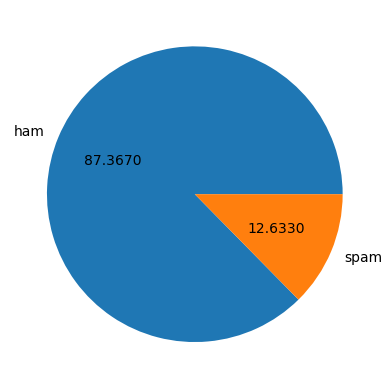

In [17]:
import matplotlib.pyplot as plt

plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct='%0.4f')

In [18]:
# data is imbalanced

In [19]:
import nltk

In [20]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/blixture/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
df.text.apply(len)

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: text, Length: 5169, dtype: int64

In [22]:
df['num_char'] = df.text.apply(len)

In [23]:
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [24]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [25]:
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [26]:
df.head()

,target,text,num_char,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
df[['num_char', 'num_words','num_sentences']].describe()

,num_char,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
 import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

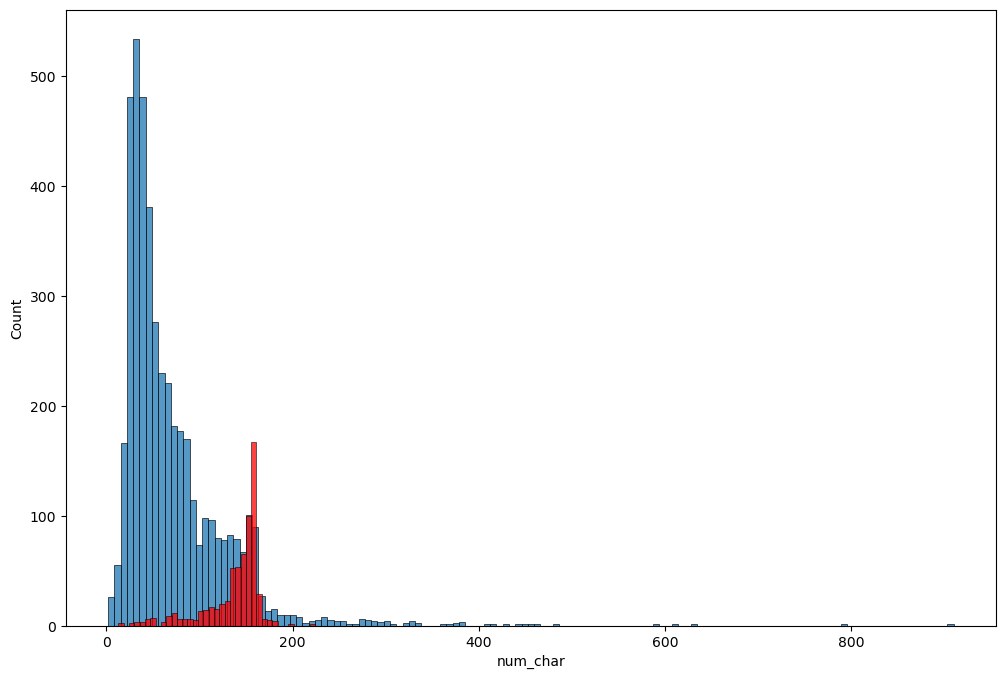

In [29]:
plt.figure(figsize=(12,8))

sns.histplot(df[df['target'] == 0]['num_char'])
sns.histplot(df[df['target'] == 1]['num_char'],color='r')

<Axes: xlabel='num_words', ylabel='Count'>

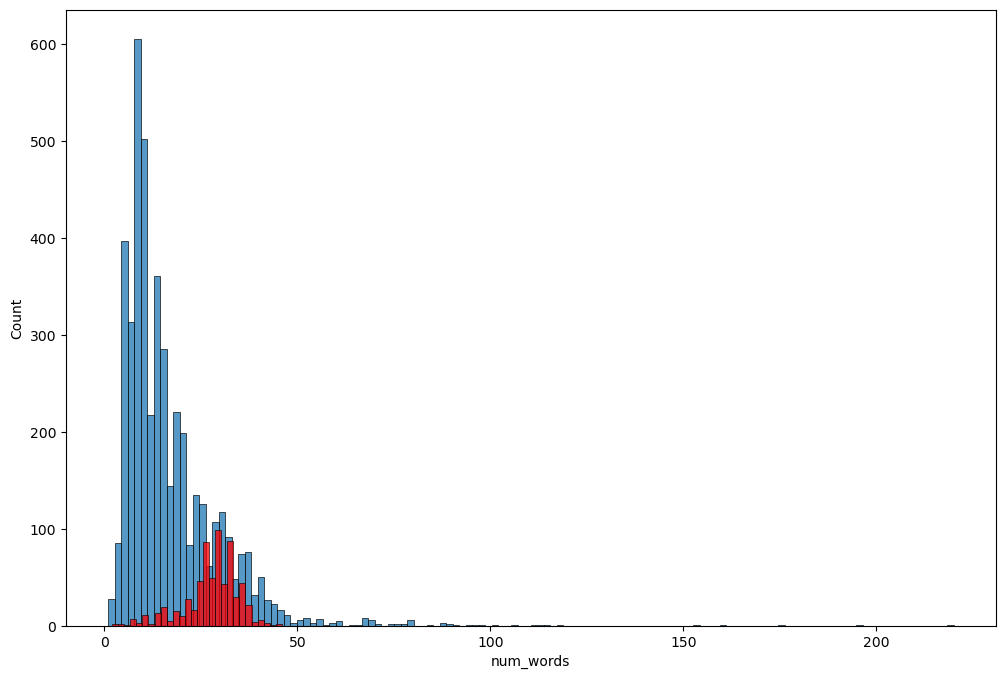

In [30]:
plt.figure(figsize=(12,8))

sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='r')

<Axes: xlabel='num_sentences', ylabel='Count'>

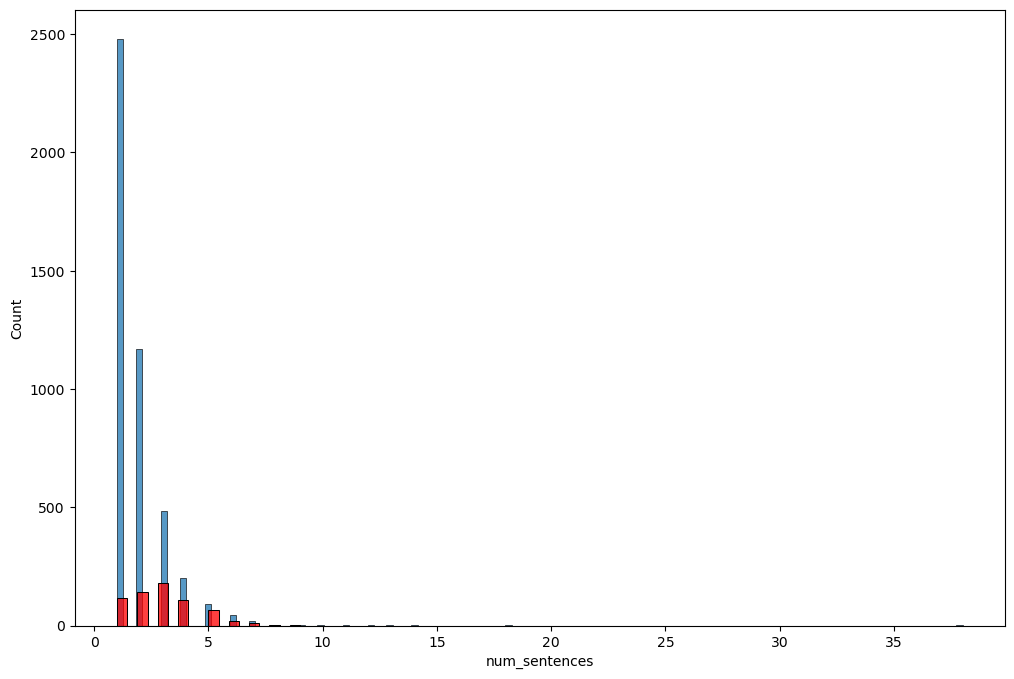

In [31]:
plt.figure(figsize=(12,8))

sns.histplot(df[df['target'] == 0]['num_sentences'])
sns.histplot(df[df['target'] == 1]['num_sentences'],color='r')

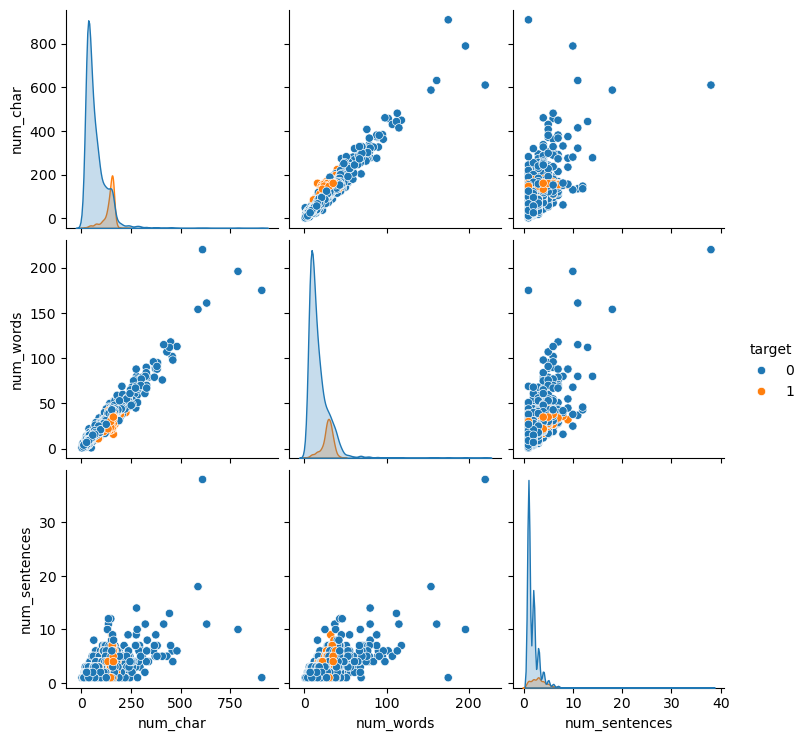

In [32]:
sns.pairplot(df, hue='target')

In [33]:
df.corr(numeric_only=True)

,target,num_char,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_char,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

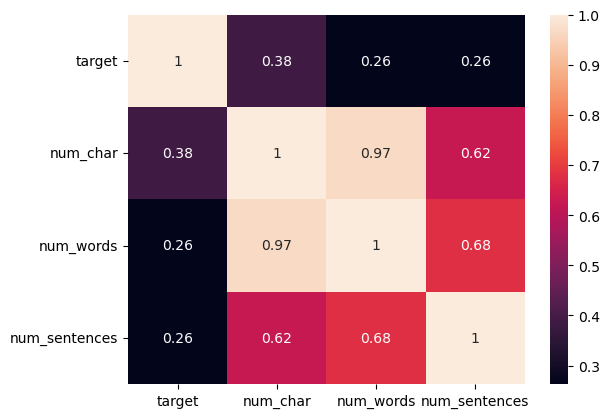

In [34]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [35]:
# data preprocessing
# lowercase -> tokenization -> removing special chars -> removing stop words and punctuation -> stemming

import nltk
nltk.download('stopwords')
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Initialize the stemmer
ps = PorterStemmer()

def transform_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Tokenization
    tokens = nltk.word_tokenize(text)
    
    # 3. Removing special characters (keeping only alphanumeric)
    algo_tokens = []
    for i in tokens:
        if i.isalnum():
            algo_tokens.append(i)
            
    # 4. Removing stop words and punctuation
    # Converting to a set makes the 'in' check incredibly fast
    stop_words = set(stopwords.words('english'))
    
    clean_tokens = []
    for i in algo_tokens:
        if i not in stop_words and i not in string.punctuation:
            # 5. Stemming (e.g., 'loving', 'loved' -> 'love')
            clean_tokens.append(ps.stem(i))
            
    # Return as a processed string (or leave as a list if you prefer)
    return " ".join(clean_tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/blixture/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
 df['transformed_text'] = df['text'].apply(transform_text)

In [37]:
df

,target,text,num_char,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [38]:
from wordcloud import WordCloud
wc = WordCloud(width=5000, height=5000, min_font_size=10, background_color='white')

In [39]:
spam_wc = wc.generate(df[df.target == 1]['transformed_text'].str.cat(sep=" "))

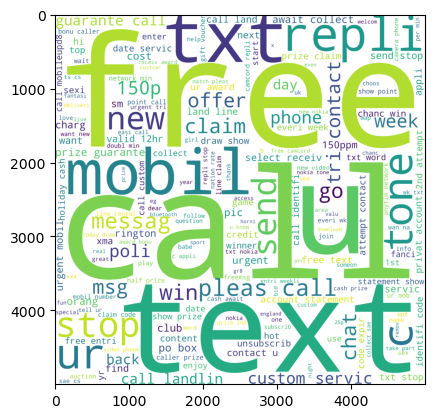

In [40]:
plt.imshow(spam_wc)

In [41]:
ham_wc = wc.generate(df[df.target == 0]['transformed_text'].str.cat(sep=" "))

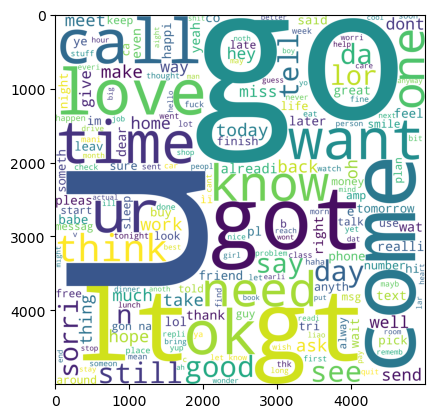

In [42]:
plt.imshow(ham_wc)

In [43]:
# top 50 most used words
spam_corpus = []
for msg in df[df.target == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

len(spam_corpus)

9939

In [44]:
import pandas as pd
from collections import Counter
pd.DataFrame(Counter(spam_corpus).most_common(30))[0]

0        call
1        free
2           2
3         txt
4        text
5           u
6          ur
7       mobil
8        stop
9       repli
10      claim
11          4
12      prize
13        get
14        new
15     servic
16       tone
17       send
18     urgent
19      nokia
20    contact
21      award
22      phone
23       cash
24      pleas
25       week
26        win
27          c
28    collect
29        min
Name: 0, dtype: str

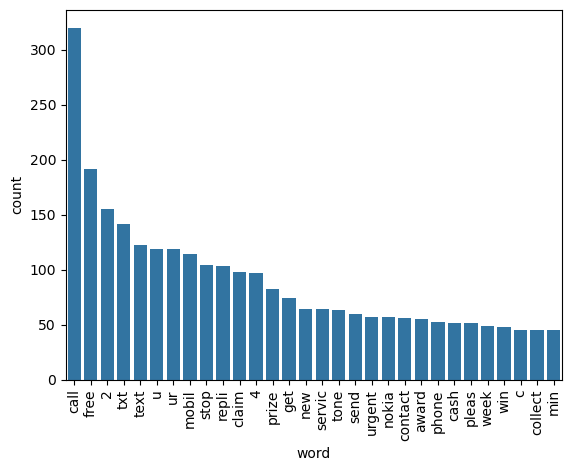

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# 1. Create the DataFrame once
top_30_spam = pd.DataFrame(Counter(spam_corpus).most_common(30))

# 2. Rename columns so your code is easy to read (0 -> 'word', 1 -> 'count')
top_30_spam.columns = ['word', 'count']

# 3. Explicitly pass x and y
sns.barplot(x='word', y='count', data=top_30_spam)
plt.xticks(rotation='vertical')
plt.show()

In [46]:
# Model Building

In [47]:
# Naive Bayes, generally best perf on textual data

# vectorizing input using bag of words or tfidf  

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

In [48]:
X = cv.fit_transform(df.transformed_text).toarray()

In [49]:
X.shape

(5169, 6708)

In [50]:
y = df.target.values

In [51]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=3)

In [54]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [55]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [56]:

# ADVANCED MODEL TRAINING (TF-IDF)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import pandas as pd

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    sublinear_tf=True
)

X = tfidf.fit_transform(df['transformed_text'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "LogisticRegression": LogisticRegression(max_iter=3000),
    "LinearSVC": LinearSVC(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
results_df.sort_values("F1", ascending=False)


,Model,Accuracy,Precision,Recall,F1
6,ExtraTrees,0.979691,0.974138,0.862595,0.914980
3,LinearSVC,0.978723,0.973913,0.854962,0.910569
1,BernoulliNB,0.975822,0.990741,0.816794,0.895397
5,RandomForest,0.973888,0.990566,0.801527,0.886076
0,MultinomialNB,0.970986,0.990291,0.778626,0.871795
7,GradientBoosting,0.964217,0.951923,0.755725,0.842553
4,DecisionTree,0.951644,0.809160,0.809160,0.809160
2,LogisticRegression,0.952611,1.000000,0.625954,0.769953
8,AdaBoost,0.928433,0.820225,0.557252,0.663636
9,KNN,0.902321,1.000000,0.229008,0.372671


In [57]:


# TRAIN BEST MODEL


best_model = LinearSVC()
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))

print(classification_report(y_test, pred))


Accuracy : 0.9787234042553191
Precision: 0.9739130434782609
Recall   : 0.8549618320610687
F1 Score : 0.9105691056910569
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.97      0.85      0.91       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [58]:


# SAVE MODEL + TFIDF


import pickle

pickle.dump(tfidf, open("vectorizer.pkl","wb"))
pickle.dump(best_model, open("model.pkl","wb"))

print("Saved model.pkl and vectorizer.pkl")


Saved model.pkl and vectorizer.pkl


In [59]:

# SINGLE MESSAGE PREDICTION

def predict_sms(text):
    transformed = transform_text(text)
    vector = tfidf.transform([transformed])
    prediction = best_model.predict(vector)[0]
    return "SPAM" if prediction == 1 else "HAM"

predict_sms("Congratulations! You have won a free iPhone. Click now.")


'HAM'